In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from glob import glob

In [4]:
csv_path = '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv'
skin_df = pd.read_csv(csv_path)
skin_df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


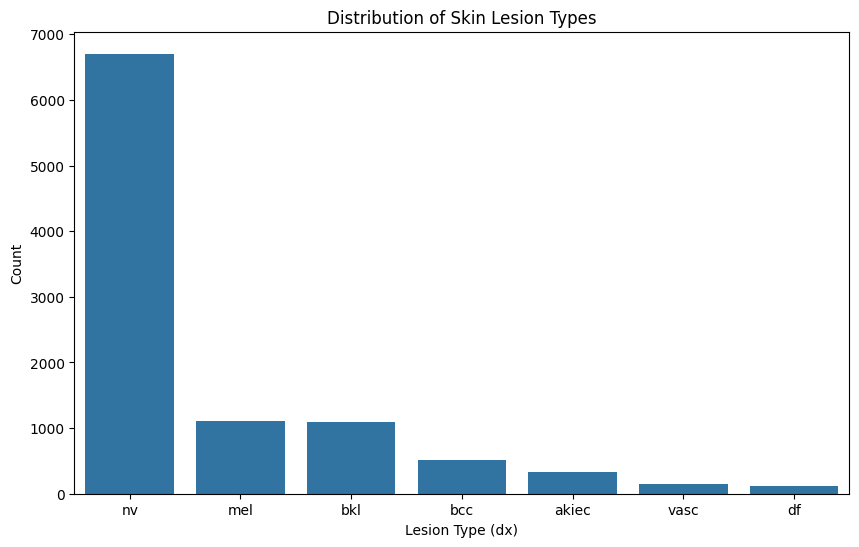

In [5]:
# Print the exact count of each lesion type (the 'dx' column stands for diagnosis)
print(skin_df['dx'].value_counts())

# Plotting the distribution as a bar chart
plt.figure(figsize=(10, 6))
sns.countplot(x='dx', data=skin_df, order=skin_df['dx'].value_counts().index)
plt.title('Distribution of Skin Lesion Types')
plt.xlabel('Lesion Type (dx)')
plt.ylabel('Count')
plt.show()

In [6]:
import os
from glob import glob

# Search for every .jpg file inside your 'data' folder (and any subfolders).
image_path_list = glob('/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/**/*.jpg', recursive=True)

# Creating a dictionary that links the image's base name to its full path.
image_path_dict = {os.path.splitext(os.path.basename(x))[0]: x for x in image_path_list}
skin_df['path'] = skin_df['image_id'].map(image_path_dict.get)
skin_df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,/kaggle/input/datasets/kmader/skin-cancer-mnis...
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,/kaggle/input/datasets/kmader/skin-cancer-mnis...
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,/kaggle/input/datasets/kmader/skin-cancer-mnis...
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,/kaggle/input/datasets/kmader/skin-cancer-mnis...
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,/kaggle/input/datasets/kmader/skin-cancer-mnis...


In [7]:
from sklearn.model_selection import StratifiedGroupKFold

# Encoding the diagnosis labels as numbers so the splitter can stratify on them
skin_df['label'] = skin_df['dx'].astype('category').cat.codes

# Separating 80% of the data for Training and leaving 20% in a temporary set (images of the same lesion stay together)
train_idx, temp_idx = next(StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=123).split(
    skin_df, skin_df['label'], groups=skin_df['lesion_id']))
train_df, temp_df = skin_df.iloc[train_idx], skin_df.iloc[temp_idx]

# Spliting that temporary 20% equally into Validation (10%) and Testing (10%)
val_idx, test_idx = next(StratifiedGroupKFold(n_splits=2, shuffle=True, random_state=123).split(
    temp_df, temp_df['label'], groups=temp_df['lesion_id']))
val_df, test_df = temp_df.iloc[val_idx], temp_df.iloc[test_idx]

# Verifying the lengths of the new dataframes and that no lesion appears in more than one set
print(f"Training set: {len(train_df)} images")
print(f"Validation set: {len(val_df)} images")
print(f"Testing set: {len(test_df)} images")
print("Lesions shared between train and test:", len(set(train_df['lesion_id']) & set(test_df['lesion_id'])))

Training set: 8036 images
Validation set: 965 images
Testing set: 1014 images
Lesions shared between train and test: 0


In [8]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# Extracting unique class names in alphabetical order
classes = np.unique(train_df['dx'])

# Calculating balanced loss weights, softened with a square root so the rare classes are not over-penalised
class_weights = np.sqrt(compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_df['dx']
))

# Converting to index dictionary for TensorFlow/Keras
class_weights_dict = dict(enumerate(class_weights))

print("Class labels order:", classes)
print("Calculated class weights:", class_weights_dict)

Class labels order: ['akiec' 'bcc' 'bkl' 'df' 'mel' 'nv' 'vasc']
Calculated class weights: {0: np.float64(2.113510366674105), 1: np.float64(1.679475757681194), 2: np.float64(1.1560439949574006), 3: np.float64(3.4762351080322214), 4: np.float64(1.1389359688950638), 5: np.float64(0.46018370929599456), 6: np.float64(3.2015621187164243)}


In [9]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Targeting image size for transfer learning model and batch size
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Training generator WITH augmentation (preprocess_input scales pixels to the -1 to 1 range MobileNetV2 was trained on)
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=180,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='reflect'
)

# Validation and Testing generators WITHOUT augmentation (only the MobileNetV2 preprocessing)
val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# Creating streaming image generators from dataframes
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df, x_col='path', y_col='dx', target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True, seed=123
)

val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df, x_col='path', y_col='dx', target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df, x_col='path', y_col='dx', target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

Found 8036 validated image filenames belonging to 7 classes.
Found 965 validated image filenames belonging to 7 classes.
Found 1014 validated image filenames belonging to 7 classes.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9069724..0.7097249].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8342087..0.854241].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.32401717..0.86161256].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.7099565].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8509853..0.71087754].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.81404257..0.94424534].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.70949364

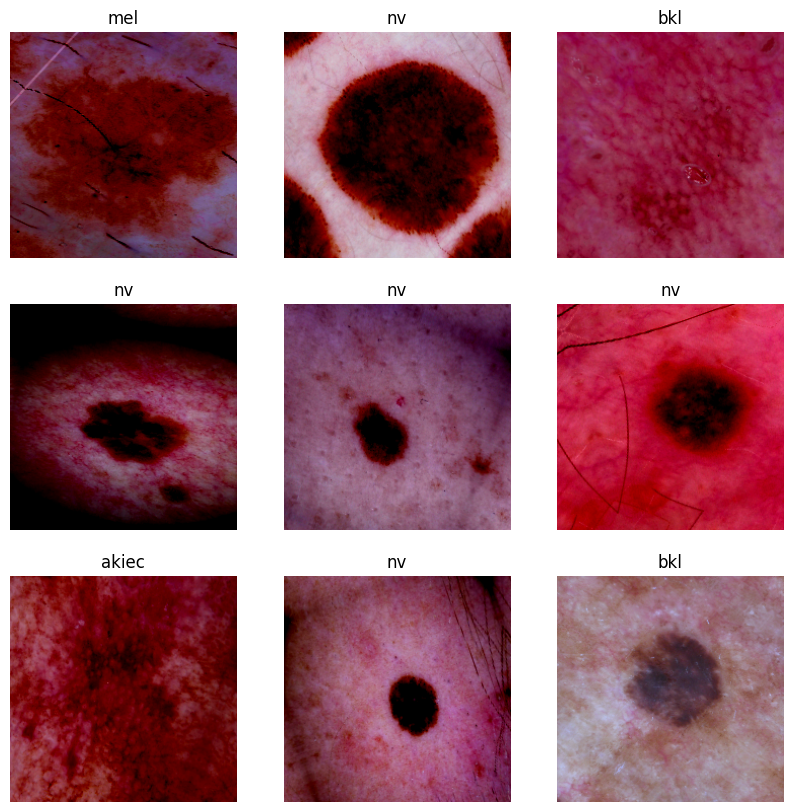

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Fetching a single batch of 32 augmented images and their one-hot encoded labels
images, labels = next(train_generator)
class_names = list(train_generator.class_indices.keys())

# Ploting a 3x3 grid of the first 9 images in the batch
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i]) # The generator already rescaled pixels to 0-1, perfect for plotting
    plt.title(class_names[np.argmax(labels[i])])
    plt.axis("off")
plt.imshow((images[i] + 1) / 2)

In [11]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Loading pre-trained MobileNetV2 base without top classifier
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# Freezing base layers so pretrained features are preserved
base_model.trainable = False

# Constructing custom classification head on top
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(7, activation='softmax')  # 7 classes
])

# Compiling model with Adam optimizer and Categorical Crossentropy loss
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall'), tf.keras.metrics.Precision(name='precision')]
)

model.summary()

I0000 00:00:1791190060.010589      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1791190060.014051      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,427,975 (9.26 MB)

 Trainable params: 167,431 (654.03 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [12]:
from tensorflow.keras.callbacks import Callback, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import recall_score

# Computing macro recall (average recall over the 7 classes) on the validation set after every epoch
class MacroRecall(Callback):
    def on_epoch_end(self, epoch, logs=None):
        val_generator.reset()
        preds = np.argmax(self.model.predict(val_generator, verbose=0), axis=1)
        logs['val_macro_recall'] = recall_score(val_generator.classes, preds, average='macro')
        print(f" - val_macro_recall: {logs['val_macro_recall']:.4f}")

# Stops training early if macro recall stops improving for 5 epochs, and keeps the best weights
early_stop = EarlyStopping(monitor='val_macro_recall', mode='max', patience=5, restore_best_weights=True)

# Reduces the learning rate if macro recall gets stuck
reduce_lr = ReduceLROnPlateau(monitor='val_macro_recall', mode='max', factor=0.5, patience=2, min_lr=1e-6)

# 2. Training (MacroRecall has to come first in the list so the other callbacks can see its value)
print("Starting training phase...")
history = model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    class_weight=class_weights_dict,
    callbacks=[MacroRecall(), early_stop, reduce_lr]
)

Starting training phase...
Epoch 1/20


2026-10-05 08:47:59.661302: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 08:47:59.799229: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1791190082.688878     142 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 56/252 ━━━━━━━━━━━━━━━━━━━━ 2:07 649ms/step - accuracy: 0.3644 - loss: 1.7318 - precision: 0.4560 - recall: 0.2687

2026-10-05 08:48:47.209914: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 08:48:47.346374: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


252/252 ━━━━━━━━━━━━━━━━━━━━ 0s 671ms/step - accuracy: 0.5136 - loss: 1.4399 - precision: 0.6109 - recall: 0.4255

2026-10-05 08:51:14.319579: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 08:51:14.455253: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 - val_macro_recall: 0.4952
252/252 ━━━━━━━━━━━━━━━━━━━━ 229s 831ms/step - accuracy: 0.5892 - loss: 1.2587 - precision: 0.6851 - recall: 0.5073 - val_accuracy: 0.7067 - val_loss: 0.8027 - val_precision: 0.8318 - val_recall: 0.5689 - val_macro_recall: 0.4952 - learning_rate: 0.0010
Epoch 2/20
252/252 ━━━━━━━━━━━━━━━━━━━━ 0s 495ms/step - accuracy: 0.6545 - loss: 1.0097 - precision: 0.7501 - recall: 0.5741 - val_macro_recall: 0.5378
252/252 ━━━━━━━━━━━━━━━━━━━━ 138s 547ms/step - accuracy: 0.6563 - loss: 0.9774 - precision: 0.7568 - recall: 0.5712 - val_accuracy: 0.6881 - val_loss: 0.8059 - val_precision: 0.8097 - val_recall: 0.5689 - val_macro_recall: 0.5378 - learning_rate: 0.0010
Epoch 3/20
252/252 ━━━━━━━━━━━━━━━━━━━━ 0s 491ms/step - accuracy: 0.6745 - loss: 0.8691 - precision: 0.7713 - recall: 0.5787 - val_macro_recall: 0.5230
252/252 ━━━━━━━━━━━━━━━━━━━━ 137s 545ms/step - accuracy: 0.6878 - loss: 0.8554 - precision: 0.7897 - recall: 0.5906 - val_accuracy: 0.7140 - val_loss: 0.7432 - 

In [13]:
# Evaluating the model on the untouched testing data
print("Evaluating model on the test set...")
test_metrics = model.evaluate(test_generator)

# Extracting and printing the specific metrics defined during compilation
print("\n--- Final Test Results ---")
print(f"Loss:      {test_metrics[0]:.4f}")
print(f"Accuracy:  {test_metrics[1]:.4f}")
print(f"Recall:    {test_metrics[2]:.4f}")
print(f"Precision: {test_metrics[3]:.4f}")

Evaluating model on the test set...
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step - accuracy: 0.6505 - loss: 0.9447 - precision: 0.7425 - recall: 0.5097

2026-10-05 09:10:20.029883: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 09:10:20.182395: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 09:10:20.319724: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


32/32 ━━━━━━━━━━━━━━━━━━━━ 22s 704ms/step - accuracy: 0.7012 - loss: 0.8125 - precision: 0.8269 - recall: 0.5937

--- Final Test Results ---
Loss:      0.8125
Accuracy:  0.7012
Recall:    0.5937
Precision: 0.8269


In [14]:
# Loading EfficientNetB0 base
base_model_eff = tf.keras.applications.EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model_eff.trainable = False  # Freeze base layers

# Building the exact same custom head on top
model_eff = models.Sequential([
    base_model_eff,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(7, activation='softmax')
])

# Compiling and training
model_eff.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall'), tf.keras.metrics.Precision(name='precision')]
)

print("Starting EfficientNetB0 training phase...")
history_eff = model_eff.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator,
    class_weight=class_weights_dict, 
    callbacks=[early_stop, reduce_lr]
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Starting EfficientNetB0 training phase...
Epoch 1/15


2026-10-05 09:10:41.046023: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 09:10:41.189685: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 09:10:41.547592: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 09:10:41.689020: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 09:10:42.507053: E external/local_xla/xla/stream_

 92/252 ━━━━━━━━━━━━━━━━━━━━ 1:18 493ms/step - accuracy: 0.3769 - loss: 1.7540 - precision: 0.4894 - recall: 0.1351

2026-10-05 09:11:39.507158: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 09:11:39.642342: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 09:11:39.962146: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 09:11:40.103759: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 09:11:40.865581: E external/local_xla/xla/stream_

252/252 ━━━━━━━━━━━━━━━━━━━━ 0s 545ms/step - accuracy: 0.4295 - loss: 1.7075 - precision: 0.5327 - recall: 0.1564

2026-10-05 09:13:22.667551: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 09:13:22.803317: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 09:13:23.125759: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 09:13:23.267401: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 09:13:24.022038: E external/local_xla/xla/stream_

252/252 ━━━━━━━━━━━━━━━━━━━━ 182s 628ms/step - accuracy: 0.4801 - loss: 1.6373 - precision: 0.5772 - recall: 0.1685 - val_accuracy: 0.6290 - val_loss: 1.7789 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/15


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_macro_recall` which is not available. Available metrics are: accuracy,loss,precision,recall,val_accuracy,val_loss,val_precision,val_recall
  current = self.get_monitor_value(logs)
/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/callback_list.py:171: UserWarning: Learning rate reduction is conditioned on metric `val_macro_recall` which is not available. Available metrics are: accuracy,loss,precision,recall,val_accuracy,val_loss,val_precision,val_recall,learning_rate.
  callback.on_epoch_end(epoch, logs)


252/252 ━━━━━━━━━━━━━━━━━━━━ 133s 527ms/step - accuracy: 0.5576 - loss: 1.4970 - precision: 0.6500 - recall: 0.1475 - val_accuracy: 0.6290 - val_loss: 1.8863 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/15
252/252 ━━━━━━━━━━━━━━━━━━━━ 132s 523ms/step - accuracy: 0.6120 - loss: 1.4403 - precision: 0.7114 - recall: 0.1208 - val_accuracy: 0.6290 - val_loss: 1.8071 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/15
252/252 ━━━━━━━━━━━━━━━━━━━━ 131s 521ms/step - accuracy: 0.6279 - loss: 1.4136 - precision: 0.7191 - recall: 0.1000 - val_accuracy: 0.6290 - val_loss: 1.7161 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 5/15
252/252 ━━━━━━━━━━━━━━━━━━━━ 132s 522ms/step - accuracy: 0.6527 - loss: 1.3979 - precision: 0.7387 - recall: 0.0932 - val_accuracy: 0.6290 - val_loss: 1.7206 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 6/15
252/252 ━━━━━━━━

In [15]:
# Evaluating the EfficientNetB0 model on the untouched testing data
print("Evaluating EfficientNetB0 on the test set...")
test_metrics_eff = model_eff.evaluate(test_generator)

# Extracting and printing the specific metrics
print("\n--- EfficientNetB0 Final Test Results ---")
print(f"Loss:      {test_metrics_eff[0]:.4f}")
print(f"Accuracy:  {test_metrics_eff[1]:.4f}")
print(f"Recall:    {test_metrics_eff[2]:.4f}")
print(f"Precision: {test_metrics_eff[3]:.4f}")

Evaluating EfficientNetB0 on the test set...
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.3503 - loss: 1.6663 - precision: 0.0000e+00 - recall: 0.0000e+00

2026-10-05 09:44:19.326260: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 09:44:19.467809: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 09:44:19.809027: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 09:44:19.951349: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 09:44:20.092802: E external/local_xla/xla/stream_

32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 456ms/step - accuracy: 0.6677 - loss: 1.4693 - precision: 0.0000e+00 - recall: 0.0000e+00

--- EfficientNetB0 Final Test Results ---
Loss:      1.4693
Accuracy:  0.6677
Recall:    0.0000
Precision: 0.0000


In [16]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

# 1. Rebuilding Generators WITHOUT rescaling (EfficientNet handles it internally)
train_datagen_eff = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest'
)
val_test_datagen_eff = ImageDataGenerator() # Blank generator, no rescaling

# 2. Re-streaming the dataframes
train_generator_eff = train_datagen_eff.flow_from_dataframe(
    dataframe=train_df, x_col='path', y_col='dx', target_size=(224, 224), 
    batch_size=32, class_mode='categorical', shuffle=True, seed=123
)
val_generator_eff = val_test_datagen_eff.flow_from_dataframe(
    dataframe=val_df, x_col='path', y_col='dx', target_size=(224, 224), 
    batch_size=32, class_mode='categorical', shuffle=False
)
test_generator_eff = val_test_datagen_eff.flow_from_dataframe(
    dataframe=test_df, x_col='path', y_col='dx', target_size=(224, 224), 
    batch_size=32, class_mode='categorical', shuffle=False
)

#  Rebuilding and Compiling EfficientNetB0
base_model_eff = tf.keras.applications.EfficientNetB0(
    input_shape=(224, 224, 3), include_top=False, weights='imagenet'
)
base_model_eff.trainable = False 

model_eff = models.Sequential([
    base_model_eff,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(7, activation='softmax')
])

model_eff.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall'), tf.keras.metrics.Precision(name='precision')]
)

# Training the unbiased model
print("Starting unbiased EfficientNetB0 training phase...")
history_eff = model_eff.fit(
    train_generator_eff,
    epochs=15,
    validation_data=val_generator_eff,
    class_weight=class_weights_dict, 
    callbacks=[early_stop, reduce_lr]
)

Found 8036 validated image filenames belonging to 7 classes.
Found 965 validated image filenames belonging to 7 classes.
Found 1014 validated image filenames belonging to 7 classes.
Starting unbiased EfficientNetB0 training phase...
Epoch 1/15
252/252 ━━━━━━━━━━━━━━━━━━━━ 164s 573ms/step - accuracy: 0.5925 - loss: 1.2989 - precision: 0.6770 - recall: 0.5063 - val_accuracy: 0.6560 - val_loss: 0.9445 - val_precision: 0.8108 - val_recall: 0.4839 - learning_rate: 0.0010
Epoch 2/15


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_macro_recall` which is not available. Available metrics are: accuracy,loss,precision,recall,val_accuracy,val_loss,val_precision,val_recall
  current = self.get_monitor_value(logs)
/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/callback_list.py:171: UserWarning: Learning rate reduction is conditioned on metric `val_macro_recall` which is not available. Available metrics are: accuracy,loss,precision,recall,val_accuracy,val_loss,val_precision,val_recall,learning_rate.
  callback.on_epoch_end(epoch, logs)


252/252 ━━━━━━━━━━━━━━━━━━━━ 125s 496ms/step - accuracy: 0.6425 - loss: 0.9774 - precision: 0.7325 - recall: 0.5562 - val_accuracy: 0.6342 - val_loss: 0.9257 - val_precision: 0.7253 - val_recall: 0.5171 - learning_rate: 0.0010
Epoch 3/15
252/252 ━━━━━━━━━━━━━━━━━━━━ 124s 493ms/step - accuracy: 0.6706 - loss: 0.9052 - precision: 0.7737 - recall: 0.5785 - val_accuracy: 0.6249 - val_loss: 0.9285 - val_precision: 0.7285 - val_recall: 0.5088 - learning_rate: 0.0010
Epoch 4/15
252/252 ━━━━━━━━━━━━━━━━━━━━ 128s 507ms/step - accuracy: 0.6893 - loss: 0.8372 - precision: 0.7947 - recall: 0.5852 - val_accuracy: 0.6653 - val_loss: 0.8285 - val_precision: 0.7569 - val_recall: 0.5710 - learning_rate: 0.0010
Epoch 5/15
252/252 ━━━━━━━━━━━━━━━━━━━━ 126s 500ms/step - accuracy: 0.6976 - loss: 0.8006 - precision: 0.7962 - recall: 0.6003 - val_accuracy: 0.6715 - val_loss: 0.8309 - val_precision: 0.7761 - val_recall: 0.5461 - learning_rate: 0.0010
Epoch 6/15
252/252 ━━━━━━━━━━━━━━━━━━━━ 126s 498ms/step - a

In [17]:
# Evaluating EfficientNetB0 using the unscaled test generator
print("Evaluating EfficientNetB0 on the unscaled test set...")
test_metrics_eff = model_eff.evaluate(test_generator_eff)

# Extracting and printing the correct test metrics
print("\n--- EfficientNetB0 Final Test Results ---")
print(f"Loss:      {test_metrics_eff[0]:.4f}")
print(f"Accuracy:  {test_metrics_eff[1]:.4f}")
print(f"Recall:    {test_metrics_eff[2]:.4f}")
print(f"Precision: {test_metrics_eff[3]:.4f}")

Evaluating EfficientNetB0 on the unscaled test set...
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 369ms/step - accuracy: 0.7170 - loss: 0.7693 - precision: 0.8142 - recall: 0.6223

--- EfficientNetB0 Final Test Results ---
Loss:      0.7693
Accuracy:  0.7170
Recall:    0.6223
Precision: 0.8142


In [ ]:
# Unfreezing the base MobileNetV2 model
base_model.trainable = True

# Freezing all lower layers except for the top 60 layers
for layer in base_model.layers[:-60]:
    layer.trainable = False

# Keeping the BatchNormalization layers frozen so small batches don't disturb their statistics
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

# 2. Recompiling with a low learning rate (1e-4) so the pretrained weights adapt gradually
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall'), tf.keras.metrics.Precision(name='precision')]
)

early_stop_fine = EarlyStopping(monitor='val_macro_recall', mode='max', patience=7, restore_best_weights=True)
reduce_lr_fine = ReduceLROnPlateau(monitor='val_macro_recall', mode='max', factor=0.5, patience=3, min_lr=1e-6)

# 3. Training the fine-tuned MobileNetV2 model
print("Starting fine-tuning phase for MobileNetV2...")
history_fine = model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    class_weight=class_weights_dict,
    callbacks=[MacroRecall(), early_stop_fine, reduce_lr_fine]
)

Starting fine-tuning phase for MobileNetV2...
Epoch 1/30
206/252 ━━━━━━━━━━━━━━━━━━━━ 23s 503ms/step - accuracy: 0.6871 - loss: 0.8839 - precision: 0.8844 - recall: 0.4739 - val_macro_recall: 0.1429
252/252 ━━━━━━━━━━━━━━━━━━━━ 142s 563ms/step - accuracy: 0.6924 - loss: 0.9020 - precision: 0.8762 - recall: 0.4854 - val_accuracy: 0.6290 - val_loss: 5.9473 - val_precision: 0.6290 - val_recall: 0.6290 - val_macro_recall: 0.1429 - learning_rate: 1.0000e-04
Epoch 5/30
252/252 ━━━━━━━━━━━━━━━━━━━━ 0s 511ms/step - accuracy: 0.7157 - loss: 0.8708 - precision: 0.8730 - recall: 0.5122 - val_macro_recall: 0.2767
252/252 ━━━━━━━━━━━━━━━━━━━━ 142s 565ms/step - accuracy: 0.7133 - loss: 0.8415 - precision: 0.8637 - recall: 0.5322 - val_accuracy: 0.6435 - val_loss: 2.5388 - val_precision: 0.6462 - val_recall: 0.6435 - val_macro_recall: 0.2767 - learning_rate: 5.0000e-05
Epoch 6/30
252/252 ━━━━━━━━━━━━━━━━━━━━ 0s 500ms/step - accuracy: 0.7196 - loss: 0.8134 - precision: 0.8612 - recall: 0.5563 - val_ma

In [ ]:
# Evaluating the fine-tuned MobileNetV2 model on the test set
print("Evaluating Fine-Tuned MobileNetV2 on the test set...")
test_metrics_fine = model.evaluate(test_generator)

# Extracting and printing the fine-tuned test metrics
print("\n--- Fine-Tuned MobileNetV2 Final Test Results ---")
print(f"Loss:      {test_metrics_fine[0]:.4f}")
print(f"Accuracy:  {test_metrics_fine[1]:.4f}")
print(f"Recall:    {test_metrics_fine[2]:.4f}")
print(f"Precision: {test_metrics_fine[3]:.4f}")

31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step - accuracy: 0.7040 - loss: 0.7302 - precision: 0.7615 - recall: 0.6499

Class scales: {'akiec': np.float64(0.68), 'bcc': np.float64(0.97), 'bkl': np.float64(0.38), 'df': np.float64(0.3), 'mel': np.float64(0.68), 'nv': np.float64(4.45), 'vasc': np.float64(0.3)}

--- Plain argmax ---

              precision    recall  f1-score   support

       akiec      0.551     0.675     0.607        40
         bcc      0.711     0.561     0.627        57
         bkl      0.474     0.705     0.567       105
          df      0.278     0.714     0.400        14
         mel      0.322     0.752     0.451       105
          nv      0.972     0.671     0.794       677
        vasc      0.938     0.938     0.938        16

    accuracy                          0.681      1014
   macro avg      0.607     0.717     0.626      1014
weighted avg      0.812     0.681     0.715      1014


--- With class scales ---

              precision    recall  f1-score   support

       akiec      0.596     0.700     0.644        40
         bcc      0.761     0.614     0.680        57


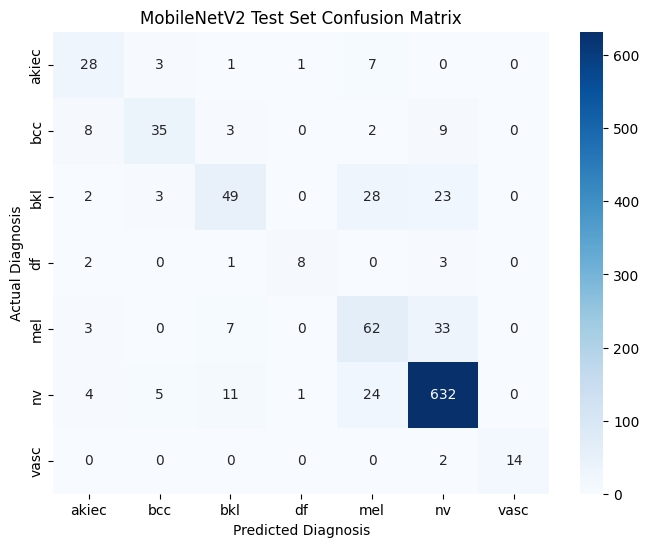

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, f1_score

# Predicting with the original image plus its flipped versions and averaging the probabilities
def predict_with_flips(generator):
    generator.reset()
    all_probs = []
    for i in range(len(generator)):
        batch_x, _ = generator[i]
        views = [batch_x, batch_x[:, :, ::-1], batch_x[:, ::-1], batch_x[:, ::-1, ::-1]]
        probs = np.mean([model.predict_on_batch(np.ascontiguousarray(v)) for v in views], axis=0)
        all_probs.append(probs)
    return np.concatenate(all_probs)

# Searching for a multiplier per class that maximises macro F1 (fitted on the validation set only)
def tune_class_scales(probs, y_true, rounds=3):
    scales = np.ones(probs.shape[1])
    grid = np.exp(np.linspace(np.log(0.3), np.log(5), 25))
    for _ in range(rounds):
        for c in range(probs.shape[1]):
            scores = []
            for g in grid:
                trial = scales.copy()
                trial[c] = g
                scores.append(f1_score(y_true, np.argmax(probs * trial, axis=1), average='macro'))
            scales[c] = grid[int(np.argmax(scores))]
    return scales

val_probs = predict_with_flips(val_generator)
test_probs = predict_with_flips(test_generator)
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

class_scales = tune_class_scales(val_probs, val_generator.classes)
print("Class scales:", dict(zip(class_labels, class_scales.round(2))))

# Reporting the test results before and after the class scaling
for name, probs in [("Plain argmax", test_probs), ("With class scales", test_probs * class_scales)]:
    print(f"\n--- {name} ---\n")
    print(classification_report(y_true, np.argmax(probs, axis=1), target_names=class_labels, digits=3))

# Plotting Heatmap
y_pred = np.argmax(test_probs * class_scales, axis=1)
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Diagnosis')
plt.ylabel('Actual Diagnosis')
plt.title('MobileNetV2 Test Set Confusion Matrix')
plt.show()

In [21]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Building the extra inputs (age, sex, body location) for every image
age_median = train_df['age'].median()
age_mean = train_df['age'].fillna(age_median).mean()
age_std = train_df['age'].fillna(age_median).std()
loc_categories = sorted(skin_df['localization'].unique())

def make_meta(d):
    age = ((d['age'].fillna(age_median) - age_mean) / age_std).values[:, None]
    sex = d['sex'].map({'male': 1.0, 'female': 0.0}).fillna(0.5).values[:, None]
    loc = pd.get_dummies(d['localization'].astype(pd.CategoricalDtype(loc_categories))).values
    return np.hstack([age, sex, loc]).astype('float32')

META_DIM = make_meta(train_df.head(5)).shape[1]
print("Number of metadata features:", META_DIM)

# Reading each image once (kept as small uint8 arrays in memory)
def load_image(path, meta, label, weight):
    img = tf.io.decode_jpeg(tf.io.read_file(path), channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    return tf.cast(tf.round(img), tf.uint8), meta, label, weight

# Applying the MobileNetV2 preprocessing and packing the two inputs together
def pack_train(img, meta, label, weight):
    return {'image': preprocess_input(tf.cast(img, tf.float32)), 'meta': meta}, label, weight

def pack_eval(img, meta, label, weight):
    return {'image': preprocess_input(tf.cast(img, tf.float32)), 'meta': meta}, label

def make_dataset(d, training):
    labels = tf.one_hot(d['label'].values.astype('int32'), 7)
    weights = np.array([class_weights_dict[i] for i in d['label'].values], dtype='float32')
    ds = tf.data.Dataset.from_tensor_slices((d['path'].values, make_meta(d), labels, weights))
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE).cache()
    if training:
        ds = ds.shuffle(1024, seed=123).map(pack_train, num_parallel_calls=tf.data.AUTOTUNE)
    else:
        ds = ds.map(pack_eval, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(train_df, True)
val_ds = make_dataset(val_df, False)
test_ds = make_dataset(test_df, False)

Number of metadata features: 17


In [22]:
from tensorflow.keras import layers, Model

# Copying the fine-tuned MobileNetV2 so the original image-only model stays untouched
image_base = tf.keras.models.clone_model(base_model)
image_base.set_weights(base_model.get_weights())
image_base.trainable = False

# Image branch (augmentation layers are only active during training)
image_input = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3), name='image')
x = layers.RandomFlip('horizontal_and_vertical')(image_input)
x = layers.RandomRotation(0.5)(x)
x = layers.RandomZoom(0.2)(x)
x = layers.RandomTranslation(0.1, 0.1)(x)
x = image_base(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)

# Metadata branch
meta_input = layers.Input(shape=(META_DIM,), name='meta')
m = layers.Dense(32, activation='relu')(meta_input)
m = layers.Dropout(0.2)(m)

# Joining both branches and classifying into the 7 diagnoses
combined = layers.Concatenate()([x, m])
combined = layers.Dense(128, activation='relu')(combined)
combined = layers.Dropout(0.3)(combined)
output = layers.Dense(7, activation='softmax')(combined)

model_meta = Model(inputs={'image': image_input, 'meta': meta_input}, outputs=output)
model_meta.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_flip         │ (None, 224, 224,  │          0 │ image[0][0]       │
│ (RandomFlip)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_rotation     │ (None, 224, 224,  │          0 │ random_flip[0][0] │
│ (RandomRotation)    │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_zoom         │ (None, 224, 224,  │          0 │ random_rotation[… │
│ (RandomZoom)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_translation  │ (None, 224, 224,  │          0 │ random_zoom[0][0] │
│ (RandomTranslation) │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 7, 7,      │  2,257,984 │ random_translati… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ meta (InputLayer)   │ (None, 17)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 32)        │        576 │ meta[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 1280)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 32)        │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 1312)      │          0 │ dropout_6[0][0],  │
│ (Concatenate)       │                   │            │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 128)       │    168,064 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 128)       │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 7)         │        903 │ dropout_8[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,427,527 (9.26 MB)

 Trainable params: 169,543 (662.28 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [25]:
from tensorflow.keras.callbacks import Callback, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import recall_score

# Computing macro recall on the validation set after every epoch
class MacroRecallMeta(Callback):
    def on_epoch_end(self, epoch, logs=None):
        preds = np.argmax(self.model.predict(val_ds, verbose=0), axis=1)
        logs['val_macro_recall'] = recall_score(val_df['label'].values, preds, average='macro')
        print(f" - val_macro_recall: {logs['val_macro_recall']:.4f}")

def compile_meta(lr):
    model_meta.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

# 1. Training the new layers while the image model is frozen
compile_meta(1e-3)
print("Starting metadata model head training...")
history_meta = model_meta.fit(
    train_ds,
    epochs=12,
    validation_data=val_ds,
    callbacks=[MacroRecallMeta(),
               EarlyStopping(monitor='val_macro_recall', mode='max', patience=4, restore_best_weights=True),
               ReduceLROnPlateau(monitor='val_macro_recall', mode='max', factor=0.5, patience=2, min_lr=1e-6)]
)

# 2. Unfreezing the top 60 layers of the image model (BatchNormalization stays frozen)
image_base.trainable = True
for layer in image_base.layers[:-60]:
    layer.trainable = False
for layer in image_base.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

compile_meta(1e-4)
print("Starting metadata model fine-tuning...")
history_meta_fine = model_meta.fit(
    train_ds,
    epochs=30,
    validation_data=val_ds,
    callbacks=[MacroRecallMeta(),
               EarlyStopping(monitor='val_macro_recall', mode='max', patience=7, restore_best_weights=True),
               ReduceLROnPlateau(monitor='val_macro_recall', mode='max', factor=0.5, patience=3, min_lr=1e-6)]
)
model_meta.save('mobilenetv2_with_metadata.keras')

Starting metadata model head training...
Epoch 1/12
251/252 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.4988 - loss: 1.8547 - val_macro_recall: 0.2031
252/252 ━━━━━━━━━━━━━━━━━━━━ 34s 103ms/step - accuracy: 0.6562 - loss: 1.1842 - val_accuracy: 0.2964 - val_loss: 3.4091 - val_macro_recall: 0.2031 - learning_rate: 0.0010
Epoch 2/12
251/252 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.3689 - loss: 2.5490 - val_macro_recall: 0.1429
252/252 ━━━━━━━━━━━━━━━━━━━━ 22s 87ms/step - accuracy: 0.6745 - loss: 1.5392 - val_accuracy: 0.6290 - val_loss: 1.7071 - val_macro_recall: 0.1429 - learning_rate: 0.0010
Epoch 3/12
251/252 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.3955 - loss: 1.9022 - val_macro_recall: 0.1429
252/252 ━━━━━━━━━━━━━━━━━━━━ 21s 85ms/step - accuracy: 0.6676 - loss: 1.2928 - val_accuracy: 0.6290 - val_loss: 1.6694 - val_macro_recall: 0.1429 - learning_rate: 0.0010
Epoch 4/12
251/252 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.3712 - loss: 2.0074 - val_macro_recall:


--- MobileNetV2 + metadata (plain argmax) ---

              precision    recall  f1-score   support

       akiec      0.000     0.000     0.000        40
         bcc      0.000     0.000     0.000        57
         bkl      0.000     0.000     0.000       105
          df      0.000     0.000     0.000        14
         mel      0.000     0.000     0.000       105
          nv      0.668     1.000     0.801       677
        vasc      0.000     0.000     0.000        16

    accuracy                          0.668      1014
   macro avg      0.095     0.143     0.114      1014
weighted avg      0.446     0.668     0.535      1014



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


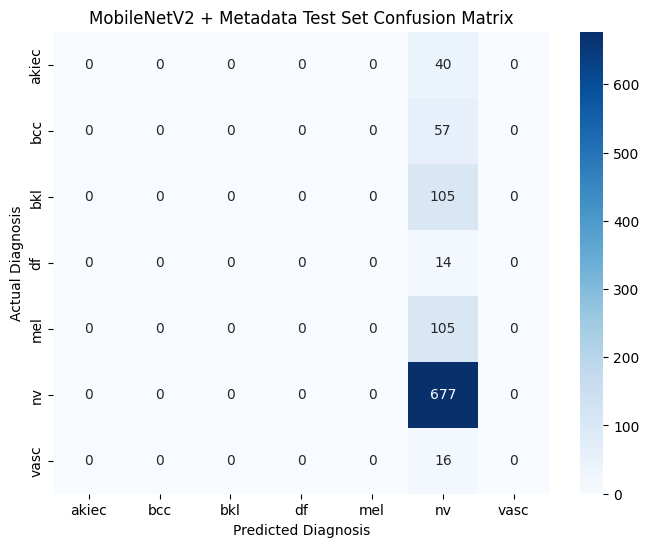

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Predicting with the original image plus its flipped versions and averaging the probabilities
def predict_meta_with_flips(ds):
    all_probs = []
    for inputs, _ in ds:
        img, meta = inputs['image'], inputs['meta']
        views = [img, tf.reverse(img, [2]), tf.reverse(img, [1]), tf.reverse(img, [1, 2])]
        probs = np.mean([model_meta.predict_on_batch({'image': v, 'meta': meta}) for v in views], axis=0)
        all_probs.append(probs)
    return np.concatenate(all_probs)

test_probs_meta = predict_meta_with_flips(test_ds)
y_true_meta = test_df['label'].values
y_pred_meta = np.argmax(test_probs_meta, axis=1)
class_labels = list(test_generator.class_indices.keys())

print("\n--- MobileNetV2 + metadata (plain argmax) ---\n")
print(classification_report(y_true_meta, y_pred_meta, target_names=class_labels, digits=3))

cm = confusion_matrix(y_true_meta, y_pred_meta)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Diagnosis')
plt.ylabel('Actual Diagnosis')
plt.title('MobileNetV2 + Metadata Test Set Confusion Matrix')
plt.show()

In [27]:
# 1. Validation macro recall of the metadata model after each epoch
print("Head training :", history_meta.history.get('val_macro_recall'))
print("Fine-tuning   :", history_meta_fine.history.get('val_macro_recall'))

# 2. Testing the new data pipeline with the original image-only model (should score about 0.75 accuracy)
val_img_ds = val_ds.map(lambda inputs, label: (inputs['image'], label))
print("Original model on the new pipeline [loss, accuracy, recall, precision]:", model.evaluate(val_img_ds, verbose=0))

# 3. What the metadata model predicts on the validation set (counts per class: akiec, bcc, bkl, df, mel, nv, vasc)
val_preds = np.argmax(model_meta.predict(val_ds, verbose=0), axis=1)
print("Predicted class counts:", np.bincount(val_preds, minlength=7))

Head training : [0.20310661332078134, 0.14285714285714285, 0.14285714285714285, 0.14285714285714285, 0.14285714285714285]
Fine-tuning   : [0.14285714285714285, 0.14285714285714285, 0.14285714285714285, 0.14285714285714285, 0.14285714285714285, 0.14285714285714285, 0.14285714285714285, 0.14285714285714285]
Original model on the new pipeline [loss, accuracy, recall, precision]: [0.7693930268287659, 0.7036269307136536, 0.6310880780220032, 0.7641154527664185]
Predicted class counts: [  0   0   0   0   0 965   0]
